# Project Q3: A/B Testing: The Impact of Discounts on Customer Spending

 This includes: graphs, labeled values, and final interpretation.

In [77]:
"""
Project 3: A/B Testing - Impact of Discounts on Customer Spending
Course: CS 4/5630 - Python for Computational and Data Sciences

This program generates synthetic A/B testing data, summarizes customer purchase
amounts, creates required graphs, and performs Welch's Independent Two-Sample
T-Test using scipy.stats.

Group A: Customers with no discount
Group B: Customers with a 10% discount
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [78]:
# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------

np.random.seed(42)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [79]:
# ------------------------------------------------------------
# 1. Generate synthetic customer purchase data
# ------------------------------------------------------------

group_a = np.random.normal(loc=50, scale=10, size=100)
group_b = np.random.normal(loc=55, scale=12, size=100)

group_a = np.clip(group_a, 0, None)
group_b = np.clip(group_b, 0, None)

In [80]:
# ------------------------------------------------------------
# 2. Load the data into a pandas DataFrame
# ------------------------------------------------------------

df = pd.DataFrame({
    "customer_id": range(1, 201),
    "group": ["A"] * 100 + ["B"] * 100,
    "purchase_amount": np.concatenate([group_a, group_b])
})

df.to_csv(os.path.join(OUTPUT_DIR, "customer_purchase_data.csv"), index=False)

In [81]:
# ------------------------------------------------------------
# 3. Display summary statistics horizontally
# ------------------------------------------------------------

summary_stats = df.groupby("group")["purchase_amount"].describe().T.round(2)

print("\nSUMMARY STATISTICS TABLE")
print("=" * 40)
print(summary_stats)

summary_stats.to_csv(os.path.join(OUTPUT_DIR, "summary_statistics.csv"))


SUMMARY STATISTICS TABLE
group       A       B
count  100.00  100.00
mean    48.96   55.27
std      9.08   11.44
min     23.80   31.97
25%     43.99   45.33
50%     48.73   56.01
75%     54.06   61.46
max     68.52   87.64


In [82]:
# ------------------------------------------------------------
# 4. Calculate group statistics
# ------------------------------------------------------------

mean_a = group_a.mean()
mean_b = group_b.mean()

std_a = group_a.std(ddof=1)
std_b = group_b.std(ddof=1)

mean_difference = mean_b - mean_a

In [83]:
# ------------------------------------------------------------
# 5. Perform Welch Independent Two-Sample T-Test
# ------------------------------------------------------------

t_statistic, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

alpha = 0.05
decision = "Reject H0" if p_value < alpha else "Fail to reject H0"

In [84]:
# ------------------------------------------------------------
# 6. Print and save final statistical results
# ------------------------------------------------------------

results_text = f"""
A/B TESTING RESULTS
===================

Group A Mean Purchase Amount: ${mean_a:.2f}
Group B Mean Purchase Amount: ${mean_b:.2f}
Mean Difference (B - A): ${mean_difference:.2f}

Group A Standard Deviation: {std_a:.2f}
Group B Standard Deviation: {std_b:.2f}

Welch Independent Two-Sample T-Test
-----------------------------------
t-statistic: {t_statistic:.4f}
p-value: {p_value:.8f}
alpha: {alpha}
Decision: {decision}

Interpretation:
Because the p-value is below the 0.05 significance level, the null hypothesis
is rejected. This means there is statistically significant evidence that the
10% discount changes average customer spending.

The negative t-statistic is not an error. It only shows direction because the
test compares Group A minus Group B. Since Group B has the higher mean purchase
amount, the t-statistic is negative.

Final Conclusion:
The 10% discount has a statistically significant positive effect on customer
purchase amount.
"""

print(results_text)

with open(os.path.join(OUTPUT_DIR, "ttest_results.txt"), "w", encoding="utf-8") as file:
    file.write(results_text)


A/B TESTING RESULTS

Group A Mean Purchase Amount: $48.96
Group B Mean Purchase Amount: $55.27
Mean Difference (B - A): $6.31

Group A Standard Deviation: 9.08
Group B Standard Deviation: 11.44

Welch Independent Two-Sample T-Test
-----------------------------------
t-statistic: -4.3164
p-value: 0.00002560
alpha: 0.05
Decision: Reject H0

Interpretation:
Because the p-value is below the 0.05 significance level, the null hypothesis
is rejected. This means there is statistically significant evidence that the
10% discount changes average customer spending.

The negative t-statistic is not an error. It only shows direction because the
test compares Group A minus Group B. Since Group B has the higher mean purchase
amount, the t-statistic is negative.

Final Conclusion:
The 10% discount has a statistically significant positive effect on customer
purchase amount.



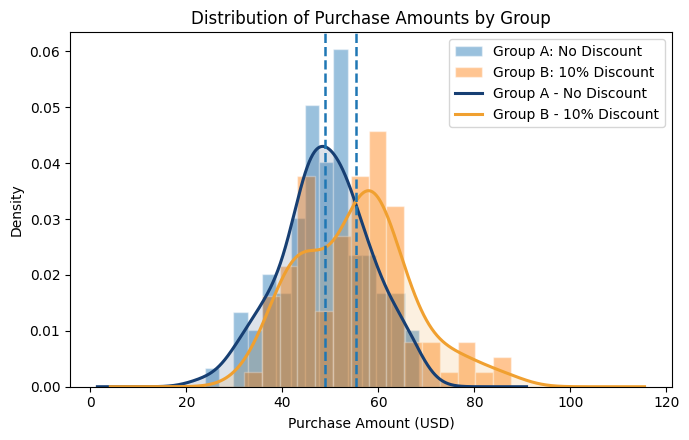

In [85]:
# ------------------------------------------------------------
# Graph 1: Combined Histogram + KDE + Mean Reference Lines
# ------------------------------------------------------------

plt.figure(figsize=(7, 4.5))

# Histogram for Group A
plt.hist(
    group_a,
    bins=15,
    density=True,
    alpha=0.45,
    edgecolor="white",
    label="Group A: No Discount"
)

# Histogram for Group B
plt.hist(
    group_b,
    bins=15,
    density=True,
    alpha=0.45,
    edgecolor="white",
    label="Group B: 10% Discount"
)

# KDE smooth curves
kde_a = pd.Series(group_a).plot(
    kind="kde",
    label="Group A - No Discount",
    linewidth=2.2,
    color="#173f73"
)

kde_b = pd.Series(group_b).plot(
    kind="kde",
    label="Group B - 10% Discount",
    linewidth=2.2,
    color="#f0a030"
)

x1 = kde_a.get_lines()[0].get_xdata()
y1 = kde_a.get_lines()[0].get_ydata()
plt.fill_between(x1, y1, alpha=0.15, color="#173f73")

x2 = kde_b.get_lines()[1].get_xdata()
y2 = kde_b.get_lines()[1].get_ydata()
plt.fill_between(x2, y2, alpha=0.15, color="#f0a030")

# Add dashed vertical mean lines
plt.axvline(mean_a, linestyle="--", linewidth=1.8)
plt.axvline(mean_b, linestyle="--", linewidth=1.8)

plt.title("Distribution of Purchase Amounts by Group")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "figure1_combined_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

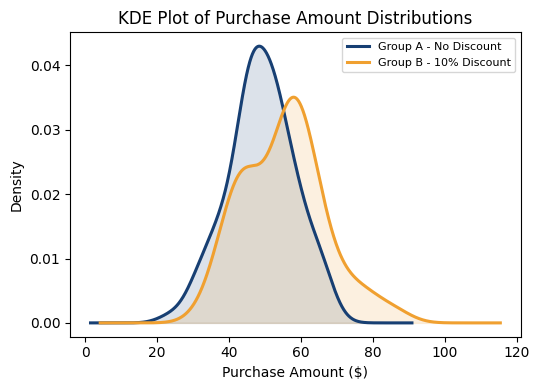

In [86]:
# ------------------------------------------------------------
# 8. Graph 2: KDE plot of purchase amount distributions
# ------------------------------------------------------------

plt.figure(figsize=(5.5, 4))

kde_a = pd.Series(group_a).plot(
    kind="kde",
    label="Group A - No Discount",
    linewidth=2.2,
    color="#173f73"
)

kde_b = pd.Series(group_b).plot(
    kind="kde",
    label="Group B - 10% Discount",
    linewidth=2.2,
    color="#f0a030"
)

x1 = kde_a.get_lines()[0].get_xdata()
y1 = kde_a.get_lines()[0].get_ydata()
plt.fill_between(x1, y1, alpha=0.15, color="#173f73")

x2 = kde_b.get_lines()[1].get_xdata()
y2 = kde_b.get_lines()[1].get_ydata()
plt.fill_between(x2, y2, alpha=0.15, color="#f0a030")
plt.title("KDE Plot of Purchase Amount Distributions")
plt.xlabel("Purchase Amount ($)")
plt.ylabel("Density")
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "figure2_kde_purchase_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

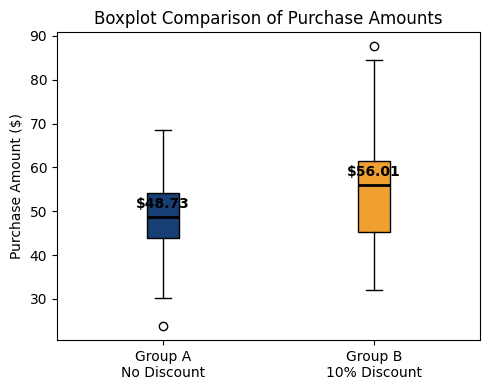

In [87]:
# ------------------------------------------------------------
# 9. Graph 3: Boxplot comparison with median values
# ------------------------------------------------------------

plt.figure(figsize=(5, 4))

box = plt.boxplot(
    [group_a, group_b],
    tick_labels=["Group A\nNo Discount", "Group B\n10% Discount"],
    patch_artist=True,
    
    medianprops=dict(color="black", linewidth=2)
)
box['boxes'][0].set_facecolor("#173f73")   # Group A blue
box['boxes'][1].set_facecolor("#f0a030")   # Group B orange
median_a = np.median(group_a)
median_b = np.median(group_b)

plt.text(1, median_a + 2, f"${median_a:.2f}", ha="center", fontweight="bold")
plt.text(2, median_b + 2, f"${median_b:.2f}", ha="center", fontweight="bold")

plt.title("Boxplot Comparison of Purchase Amounts")
plt.ylabel("Purchase Amount ($)")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "figure3_boxplot_purchase_amounts.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

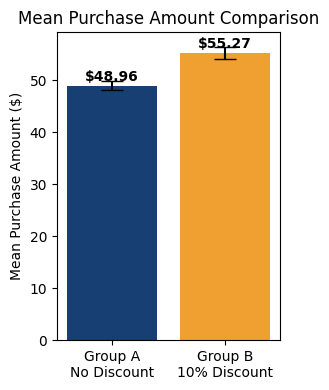

In [88]:
# ------------------------------------------------------------
# 10. Graph 4: Mean purchase comparison with error bars
# ------------------------------------------------------------

means = [mean_a, mean_b]
std_errors = [
    std_a / np.sqrt(len(group_a)),
    std_b / np.sqrt(len(group_b))
]

plt.figure(figsize=(3, 4))

bars = plt.bar(
    ["Group A\nNo Discount", "Group B\n10% Discount"],
    means,
    yerr=std_errors,
    capsize=8,
    color=["#173f73", "#f0a030"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.0,
        f"${height:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.title("Mean Purchase Amount Comparison")
plt.ylabel("Mean Purchase Amount ($)")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "figure4_mean_purchase_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()




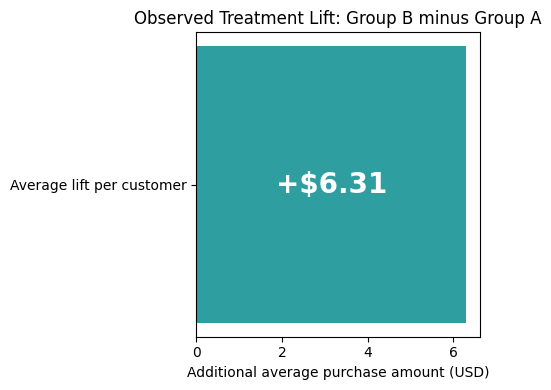


All output files have been saved successfully inside the outputs folder.


In [89]:
# ------------------------------------------------------------
# 11. Graph 5: Observed Treatment Lift
# ------------------------------------------------------------

lift = mean_b - mean_a

plt.figure(figsize=(5, 4))

bar = plt.barh(
    ["Average lift per customer"],
    [lift],
    color="#2f9ea0"
)

# Display lift value inside the bar
plt.text(
    lift / 2,
    0,
    f"+${lift:.2f}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="white"
)

plt.title("Observed Treatment Lift: Group B minus Group A")
plt.xlabel("Additional average purchase amount (USD)")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "figure5_observed_treatment_lift.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nAll output files have been saved successfully inside the outputs folder.")